The Boston Housing Dataset

The Boston Housing Dataset is a derived from information collected by the U.S. Census Service concerning housing in the area of Boston MA. The following describes the dataset columns:

* CRIM - per capita crime rate by town
* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS - proportion of non-retail business acres per town.
* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX - nitric oxides concentration (parts per 10 million)
* RM - average number of rooms per dwelling
* AGE - proportion of owner-occupied units built prior to 1940
* DIS - weighted distances to five Boston employment centres
* RAD - index of accessibility to radial highways
* TAX - full-value property-tax rate per $10,000
* PTRATIO - pupil-teacher ratio by town
* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT - % lower status of the population
* MEDV - Median value of owner-occupied homes in $1000's

In [1]:
import numpy as np
import pandas as pd
from pandas import read_csv



In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [3]:
df = pd.read_csv('housing.csv', header=None, names=column_names, sep=r'\s+')
print(f"Shape: {df.shape}")
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Split First (before cleaning to prevent data leakage)

Split 70 / 15 / 15 → 354 train, 76 val, 76 test.

In [4]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(df, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.15 / 0.85, random_state=42)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
assert len(train) + len(val) + len(test) == len(df)

Train: 354, Val: 76, Test: 76


## EDA (on train split only)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Descriptive Statistics (train) ===")
display(train.describe())

print("\n=== Null Values (train) ===")
print(train.isnull().sum())

=== Descriptive Statistics (train) ===


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000,354.000000
mean,3.815281,11.752825,11.197542,0.070621,0.554366,6.311333,68.120339,3.824086,9.387006,407.206215,18.331356,352.674802,12.379492,22.734746
std,9.350961,23.379437,7.059631,0.256554,0.116120,0.717470,28.309306,2.142882,8.665973,167.604400,2.213941,96.473180,7.009767,9.466386
min,0.009060,0.000000,1.210000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,188.000000,12.600000,0.320000,1.730000,5.000000
25%,0.074045,0.000000,5.130000,0.000000,0.448000,5.896500,44.575000,2.042000,4.000000,281.000000,16.800000,372.182500,6.800000,17.125000
50%,0.245415,0.000000,9.125000,0.000000,0.538000,6.224500,76.950000,3.207450,5.000000,330.000000,18.800000,391.115000,10.610000,21.400000
75%,3.519827,20.000000,18.100000,0.000000,0.624000,6.635000,93.725000,5.442150,24.000000,666.000000,20.200000,395.627500,16.457500,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,10.710300,24.000000,711.000000,22.000000,396.900000,34.770000,50.000000



=== Null Values (train) ===
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


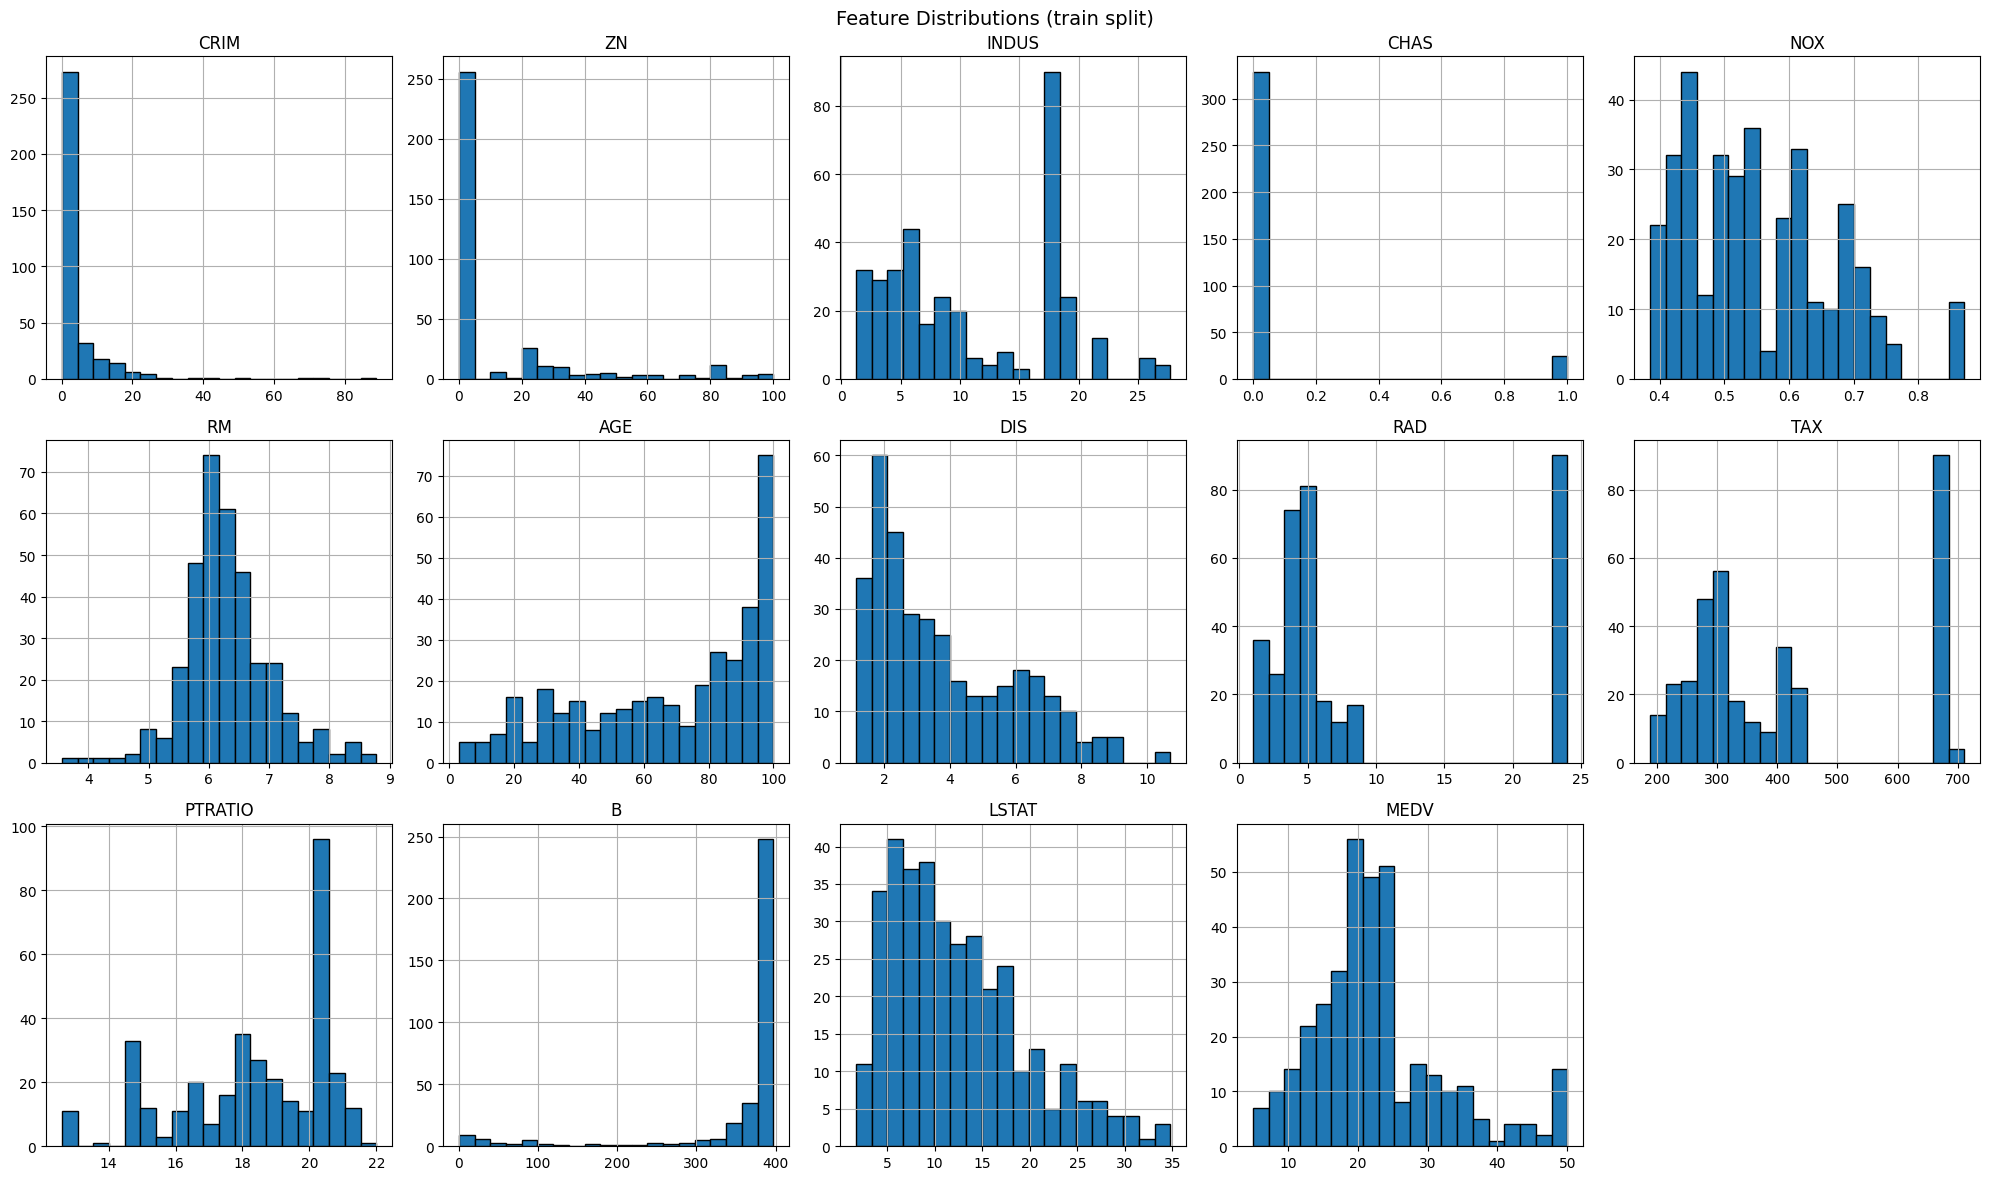

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for i, col in enumerate(column_names):
    ax = axes[i // 5, i % 5]
    train[col].hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(col)
axes[2, 4].set_visible(False)  # 14 cols → last subplot unused
plt.suptitle("Feature Distributions (train split)", fontsize=14)
plt.tight_layout()
plt.show()

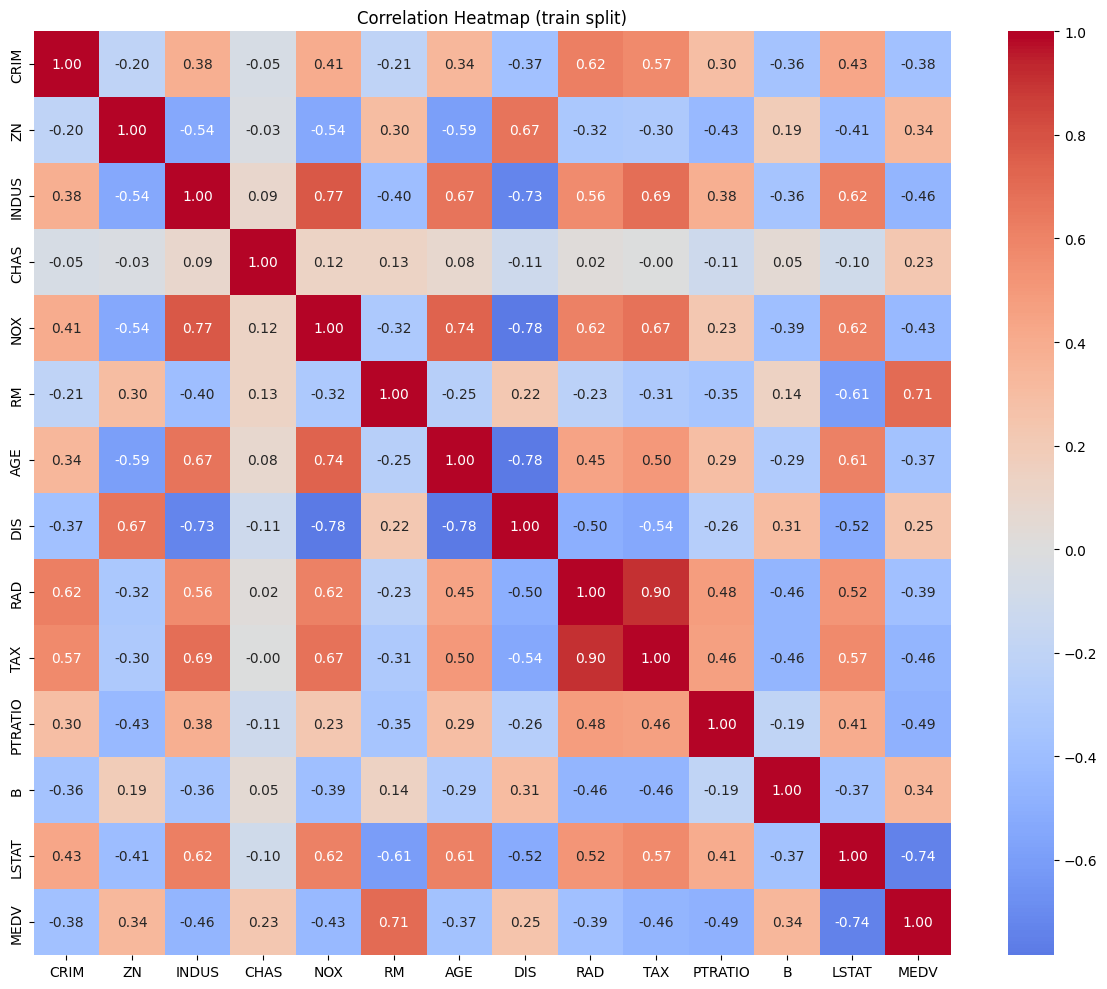

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (train split)")
plt.tight_layout()
plt.show()

In [8]:
Q1 = train.quantile(0.25)
Q3 = train.quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((train < Q1 - 1.5 * IQR) | (train > Q3 + 1.5 * IQR)).sum()
print("=== Outliers per column (IQR method, train) ===")
print(outlier_counts)

=== Outliers per column (IQR method, train) ===
CRIM       50
ZN         32
INDUS       0
CHAS       25
NOX         0
RM         23
AGE         0
DIS         2
RAD         0
TAX         0
PTRATIO     0
B          52
LSTAT       4
MEDV       31
dtype: int64


## Cleaning

Clip each feature at 1st and 99th percentile of the **train split**. Apply same bounds to val and test to prevent leakage. MEDV (target) is not clipped.

In [9]:
feature_cols = [c for c in column_names if c != 'MEDV']

clip_bounds = {
    col: (train[col].quantile(0.01), train[col].quantile(0.99))
    for col in feature_cols
}

def apply_cleaning(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df

train_clean = apply_cleaning(train, clip_bounds)
val_clean   = apply_cleaning(val,   clip_bounds)
test_clean  = apply_cleaning(test,  clip_bounds)

print("Cleaning complete.")
print(f"  Train: {train_clean.shape}, Val: {val_clean.shape}, Test: {test_clean.shape}")

Cleaning complete.
  Train: (354, 14), Val: (76, 14), Test: (76, 14)


## Export splits for regressopt integration test

`make_datafiles` globs `*.csv` from each directory, so each split goes into its own subdirectory.

In [10]:
import os

os.makedirs('Training',   exist_ok=True)
os.makedirs('Validation', exist_ok=True)
os.makedirs('Testing',    exist_ok=True)

train_clean.to_csv('Training/train.csv',   index=False)
val_clean.to_csv(  'Validation/val.csv',   index=False)
test_clean.to_csv( 'Testing/test.csv',     index=False)

print("Exported:")
print(f"  Training/train.csv   — {len(train_clean)} rows")
print(f"  Validation/val.csv   — {len(val_clean)} rows")
print(f"  Testing/test.csv     — {len(test_clean)} rows")

Exported:
  Training/train.csv   — 354 rows
  Validation/val.csv   — 76 rows
  Testing/test.csv     — 76 rows
